In [255]:
import io
from collections import defaultdict
from typing import Literal

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import yaml
from matplotlib.ticker import FuncFormatter
from plotly.offline import iplot
from scipy.stats import genpareto, lognorm

from pandemic_model.constants import NON_RESP_VIRUSES, RECURRING_VIRUSES
from pandemic_model.stats.mevd import MEVD
from pandemic_model.stats.pareto import TruncatedGPD


In [256]:
# Set seaborn style for publication-quality figures
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
'font.family': 'sans-serif',
'font.sans-serif': ['Arial'],
'font.size': 10,
'axes.titlesize': 12,
'axes.labelsize': 11,
'xtick.labelsize': 10,
'ytick.labelsize': 10,
'legend.fontsize': 10,
'legend.title_fontsize': 11
})

In [257]:
all_epidemics_ds = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
all_epidemics_ds = all_epidemics_ds.rename(columns={'severity_smu': 'severity'}) # Name change simplifies code later

In [258]:
all_epidemics_ds.loc[all_epidemics_ds['disease'] == 'hiv/aids', 'duration'] = 40

In [259]:
# Define airborne pandemics
all_epidemics_ds['airborne'] = all_epidemics_ds['transmission'].isin(['droplet', 'airborne/droplet', 'airborne/droplet/fluid'])

In [260]:
with open("../../data/clean/inverted_covid_severity.yaml", 'rb') as f:
  inverted_covid_severity_dict = yaml.safe_load(f)
  inverted_covid_severity = inverted_covid_severity_dict['ex_ante_severity']

In [261]:
all_epidemics_ds['intensity'] = all_epidemics_ds['severity'] / all_epidemics_ds['duration']

#### Construct datasets

In [262]:
bernstein_additions = ['hiv/aids', 'covid-19'] # Anything else we added?
marani_raw_ds = all_epidemics_ds[~all_epidemics_ds['disease'].isin(bernstein_additions)]
marani_fit_ds = marani_raw_ds[marani_raw_ds['year_end'].between(1600, 1945)]
all_modern_ds = all_epidemics_ds[all_epidemics_ds['year_start'] >= 1900]
modern_viral_ds = all_modern_ds[all_modern_ds['type'].str.contains('viral', case=False)]

In [263]:
modern_viral_ds['disease'].value_counts().sort_values(ascending=False)

disease
polio                         19
influenza                     18
smallpox                      13
meningitis                    11
measles                        9
dengue                         9
encephalitis                   8
yellow fever                   6
pneumonia                      5
murray valley encephalitis     4
ebola                          3
west nile                      2
rubella                        2
mumps                          1
kyasanur forest disease        1
hemorrhagic fever              1
rift valley fever              1
hiv/aids                       1
sars                           1
mers                           1
covid-19                       1
Name: count, dtype: int64

In [264]:
modern_viral_ds['transmission'].value_counts()

transmission
droplet                     47
bite                        22
droplet/feces               19
airborne/droplet            10
bite/droplet/feces/fluid     8
airborne/droplet/fluid       5
blood/fluid                  3
bite/fluid                   1
animalcontact/bite           1
fluid                        1
Name: count, dtype: int64

#### We use this list to define the constants in pandemic_model.constants

In [265]:
non_contagious = ['bite', 'animalcontact/bite']
unidentified = ['pneumonia', 'encephalitis']

In [266]:
# Ideally you would actually go through and label the whole dataset with these categories
def get_exclusion_reason(row: pd.Series) -> str:
    if row['intensity'] < 0.01:
        return 'Above detectability threshold?'
    elif 'vira' not in row['type']:
        return 'Viral?'
    elif row['disease'] in unidentified:
        return 'Identifiable?'
    elif row['transmission'] not in non_contagious:
        return 'Contagious?'
    elif row['disease'] not in ['measles', 'polio' 'mumps', 'rubella']:
        return 'Novel?'
    else:
        return 'Included'

all_modern_ds['exclusion_reason'] = all_modern_ds.apply(get_exclusion_reason, axis=1)

C:\Users\squaade\AppData\Local\Temp\ipykernel_23488\2685950223.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [267]:
def get_inclusion_path(row):
    """
    Returns a list of node labels from column 0..5, 
    stopping at the first 'fail' (exclusion).
    
    0: "Epidemics since 1900"
    1: "Below detectability threshold" or "Above detectability threshold"
    2: "Non-viral" or "Viral"
    3: "Unidentified" or "Identified"
    4: "Not contagious" or "Contagious"
    5: "Not novel" or "Novel"
    """
    path = []
    
    # Column 0
    path.append("Epidemics since 1900")
    
    # Column 1
    if row['intensity'] < 0.01:
        path.append("Below detectability threshold")
        return path
    else:
        path.append("Above detectability threshold")
    
    # Column 2
    if 'vira' not in row['type']:
        path.append("Non-viral")
        return path
    else:
        path.append("Viral")
    
    # Column 3
    if row['disease'] in unidentified:
        path.append("Unidentified")
        return path
    else:
        path.append("Identified")
    
    # Column 4
    if row['transmission'] in non_contagious:
        path.append("Not contagious")
        return path
    else:
        path.append("Contagious")
    
    # Column 5
    if row['disease'] in ['measles', 'polio', 'meningitis', 'rubella', 'smallpox']:
        path.append("Recurrent")
    else:
        path.append("Novel")
    
    return path


def plot_tidy_binary_sankey(df, title="Epidemic Exclusion Flow"):
    """
    Creates a tidy Sankey with exactly 6 columns:
      0: ["All data"]
      1: ["Below detectability threshold", "Above detectability threshold"]
      2: ["Non-viral", "Viral"]
      3: ["Unidentified", "Identified"]
      4: ["Not contagious", "Contagious"]
      5: ["Recurrent", "Novel"]
    
    We truncate each row's path at the first failure, 
    so no self-loops are produced.
    
    Flows to excluded nodes are colored gray; 
    pass flows are colored by the source node's color.
    """
    # A) Define columns
    columns = [
        ["Epidemics since 1900"], 
        ["Below detectability threshold", "Above detectability threshold"],
        ["Non-viral", "Viral"],
        ["Unidentified", "Identified"],
        ["Not contagious", "Contagious"],
        ["Recurrent", "Novel"]
    ]
    
    node_list = []
    for col in columns:
        node_list.extend(col)
    
    node_index = {lbl: i for i, lbl in enumerate(node_list)}
    
    # "excluded" nodes for coloring flows gray
    excluded_nodes = {
        "Below detectability threshold",
        "Non-viral",
        "Unidentified",
        "Not contagious",
        "Recurrent"
    }
    
    # B) Gather flows and counts
    flows = defaultdict(int)
    node_counts = defaultdict(int)
    
    for _, row in df.iterrows():
        path = get_inclusion_path(row)
        # Count nodes
        for node in path:
            node_counts[node] += 1
        # Add edges from path[i] -> path[i+1]
        for i in range(len(path) - 1):
            src, tgt = path[i], path[i+1]
            flows[(src, tgt)] += 1
    
    # Add counts to labels
    node_list_with_counts = [
        f"{lbl}<br>[n={node_counts[lbl]}]" for lbl in node_list
    ]
    
    # Build Sankey lists
    source_list = []
    target_list = []
    value_list = []
    for (s_lbl, t_lbl), count in flows.items():
        source_list.append(node_index[s_lbl])
        target_list.append(node_index[t_lbl])
        value_list.append(count)
    
    # C) Position each node in columns uniformly
    node_x = [0]*len(node_list)
    node_y = [0]*len(node_list)
    
    for col_i, col_nodes in enumerate(columns):
        if len(col_nodes) == 1:
            # e.g. column 0 has just "All data"
            n_lbl = col_nodes[0]
            idx = node_index[n_lbl]
            node_x[idx] = float(col_i)
            node_y[idx] = 0.5
        else:
            # 2 outcomes
            upper_lbl, lower_lbl = col_nodes[0], col_nodes[1]
            upper_idx = node_index[upper_lbl]
            lower_idx = node_index[lower_lbl]

            node_x[lower_idx] = float(col_i)
            node_y[lower_idx] = 0.5 

            node_x[upper_idx] = float(col_i)
            node_y[upper_idx] = 0.52
    
    # Normalize to [0,1]
    min_x, max_x = min(node_x), max(node_x)
    min_y, max_y = min(node_y), max(node_y)
    dx = max_x - min_x if max_x != min_x else 1
    dy = max_y - min_y if max_y != min_y else 1
    pad = 0.05
    node_x_norm = [pad + (x - min_x)/dx*(1-2*pad) for x in node_x]
    node_y_norm = [pad + (y - min_y)/dy*(1-2*pad) for y in node_y]
    
    # D) Colors
    color_map = {
        "Epidemics since 1900": "rgba(76,114,176,0.8)",
        "Above detectability threshold": "rgba(221,132,82,0.8)",
        "Below detectability threshold": "rgba(221,132,82,0.4)",
        "Viral": "rgba(85,168,104,0.8)",
        "Non-viral": "rgba(85,168,104,0.4)",
        "Identified": "rgba(196,78,82,0.8)",
        "Unidentified": "rgba(196,78,82,0.4)",
        "Contagious": "rgba(129,114,179,0.8)",
        "Not contagious": "rgba(129,114,179,0.4)",
        "Novel": "rgba(147,120,96,0.8)",
        "Recurrent": "rgba(147,120,96,0.4)",
    }
    
    node_colors = [
        "rgba(150,150,150,0.8)" if lbl in excluded_nodes else color_map.get(lbl, "rgba(180,180,180,0.8)")
        for lbl in node_list
    ]
    
    # Link color: if target is an "excluded" node, grey; else color by source
    link_colors = []
    for s_i, t_i in zip(source_list, target_list):
        s_lbl = node_list[s_i]
        t_lbl = node_list[t_i]
        if t_lbl in excluded_nodes:
            link_colors.append("rgba(150,150,150,0.7)")
        else:
            link_colors.append(color_map.get(s_lbl, "rgba(180,180,180,0.8)"))
    
    # E) Build Plotly Sankey
    fig = go.Figure(data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=15,
                thickness=15,
                line=dict(color="black", width=0.3),
                label=node_list_with_counts,  # Use labels with counts
                x=node_x_norm,
                y=node_y_norm,
                color=node_colors,
                hovertemplate="%{label}",
            ),
            link=dict(
                source=source_list,
                target=target_list,
                value=value_list,
                color=link_colors
            )
        )
    ])
    
    fig.update_layout(
        font=dict(family="Arial", size=12, color='black'),
        title_font_size=12,
        paper_bgcolor='white',
        plot_bgcolor='white',
        margin=dict(l=40, r=40, t=120, b=100),
        width=1200,
        height=600
    )
    
    img_bytes = pio.to_image(fig, format="png", scale=2)
    mpl_fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
    ax.imshow(plt.imread(io.BytesIO(img_bytes)))
    ax.axis("off")

    return mpl_fig, ax

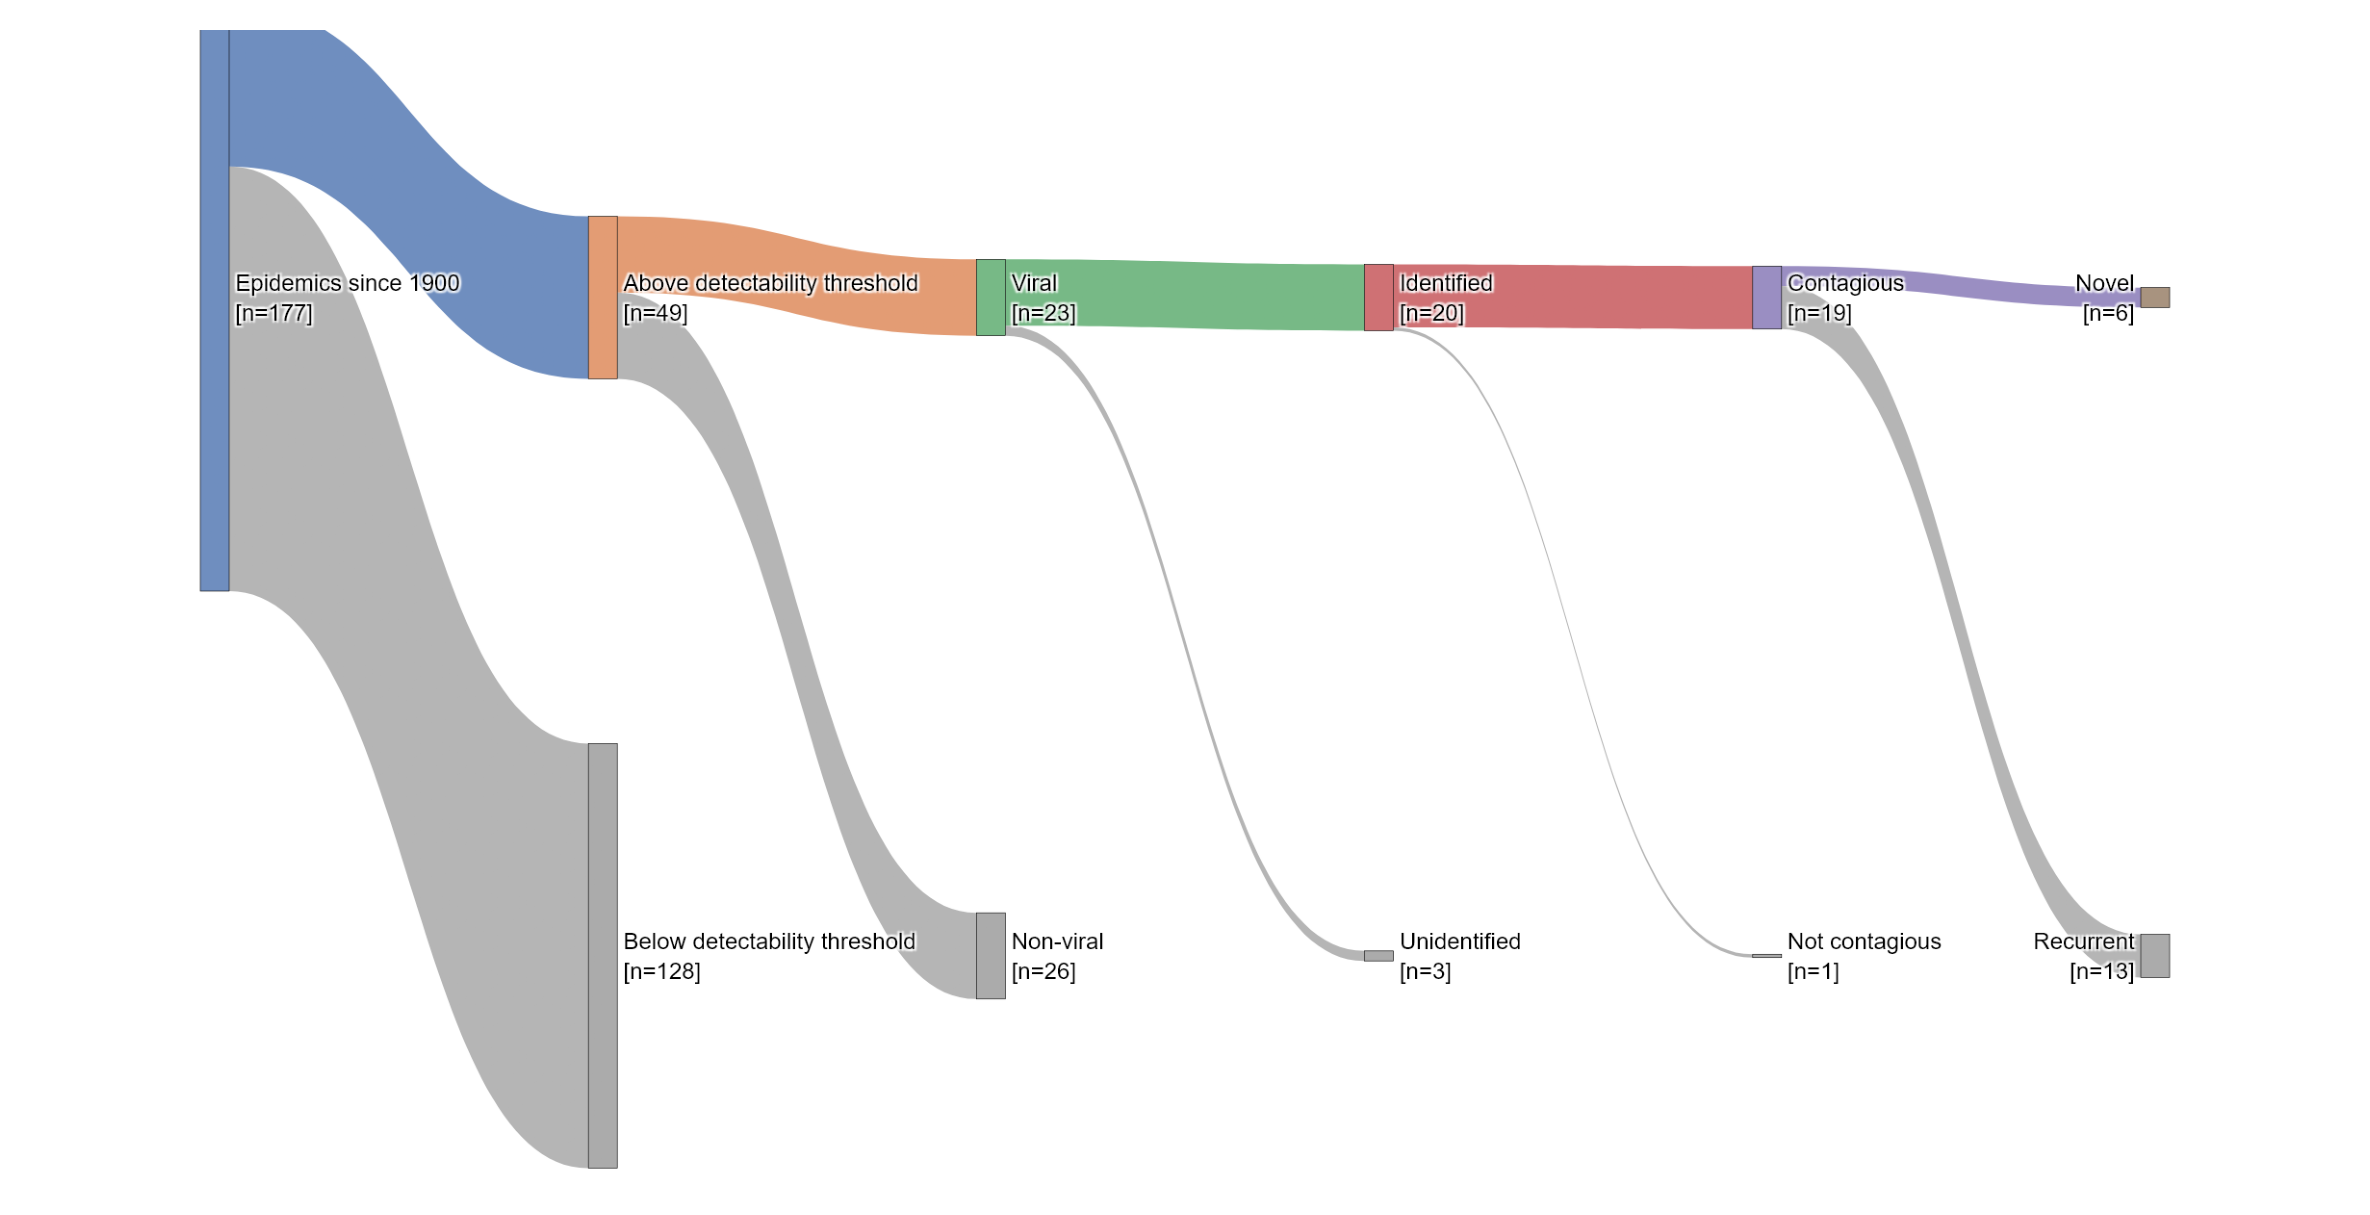

In [268]:
sankey = plot_tidy_binary_sankey(all_modern_ds)

In [252]:
def plot_epidemic_comparison(df, intensity_threshold=0.01):
    """
    Create a stacked bar plot comparing severe and non-severe epidemics using seaborn.
    
    Args:
        df: DataFrame containing epidemic data
        intensity_threshold: Threshold for what constitutes a "severe" epidemic
    """
    # Get counts by disease and intensity
    severe = df[df['intensity'] > intensity_threshold]['disease'].value_counts()
    non_severe = df[df['intensity'] <= intensity_threshold]['disease'].value_counts()
    
    # Get all unique diseases
    all_diseases = pd.concat([severe, non_severe]).index.unique()
    
    # Create a DataFrame with zeros for missing values
    plot_data = pd.DataFrame(0, index=all_diseases, columns=['Severe', 'Non-severe'])
    plot_data.loc[severe.index, 'Severe'] = severe
    plot_data.loc[non_severe.index, 'Non-severe'] = non_severe
    
    # Sort by total count
    plot_data['total'] = plot_data.sum(axis=1)
    plot_data = plot_data.sort_values('total', ascending=False)
    plot_data = plot_data.drop('total', axis=1)
    
    # Reset index to make disease a column
    plot_data = plot_data.reset_index()
    plot_data = pd.melt(plot_data, id_vars=['disease'], var_name='intensity_cat', value_name='count')
    
    # Create figure with higher DPI for publication quality
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    
    # Get viral diseases from the original dataframe
    viral_diseases = set(df[df['type'] == 'viral']['disease'].unique())
    
    # Create stacked bar plot with seaborn
    sns.barplot(data=plot_data[plot_data['intensity_cat'] == 'Severe'], 
                x='disease', y='count',
                color='#1f77b4',
                edgecolor='black',
                linewidth=1,
                ax=ax)
    
    sns.barplot(data=plot_data[plot_data['intensity_cat'] == 'Non-severe'],
                x='disease', y='count',
                color='white',
                edgecolor='black',
                linewidth=1,
                bottom=plot_data[plot_data['intensity_cat'] == 'Severe'].set_index('disease')['count'],
                ax=ax)
    
    # Capitalize disease names and color them based on viral/non-viral/unidentified
    x_labels = []
    x_colors = []
    for disease in plot_data['disease'].unique():
        label = disease.title()
        x_labels.append(label)
        if disease in unidentified:
            x_colors.append('purple')
        elif disease in viral_diseases:
            x_colors.append('red')
        else:
            x_colors.append('black')
    
    # Style improvements
    ax.set_title('Epidemics since 1900', pad=20)
    ax.set_xlabel('Disease', labelpad=10)
    ax.set_ylabel('Number of epidemics', labelpad=10)
    
    # Set x-ticks and labels with colors
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, ha='right', rotation=45, rotation_mode='anchor')
    for tick, color in zip(ax.get_xticklabels(), x_colors):
        tick.set_color(color)
    ax.tick_params(axis='x', pad=-0.5)
    
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Force whole numbers
    
    # Remove top and right spines
    ax.spines[['top', 'right']].set_visible(False)
    
    # Customize legend
    handles = [plt.Rectangle((0,0),1,1, facecolor='#1f77b4', edgecolor='black', linewidth=1),
              plt.Rectangle((0,0),1,1, facecolor='white', edgecolor='black', linewidth=1),
              plt.Rectangle((0,0),0,0, color='white'),  # Empty handle for spacing
              plt.Line2D([0], [0], color='red', lw=0, marker='s', label='Viral'),
              plt.Line2D([0], [0], color='black', lw=0, marker='s', label='Non-viral'),
              plt.Line2D([0], [0], color='purple', lw=0, marker='s', label='Unidentified')]
    labels = ['Intensity ≥ 0.01 SU', 'Intensity < 0.01 SU', '', 'Viral', 'Non-viral', 'Unidentified']
    ax.legend(handles, labels, title='Categories', frameon=True, ncol=2)
    
    # Add grid for better readability
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    return fig, ax

(<Figure size 3000x1800 with 1 Axes>,
 <Axes: title={'center': 'Epidemics since 1900'}, xlabel='Disease', ylabel='Number of epidemics'>)

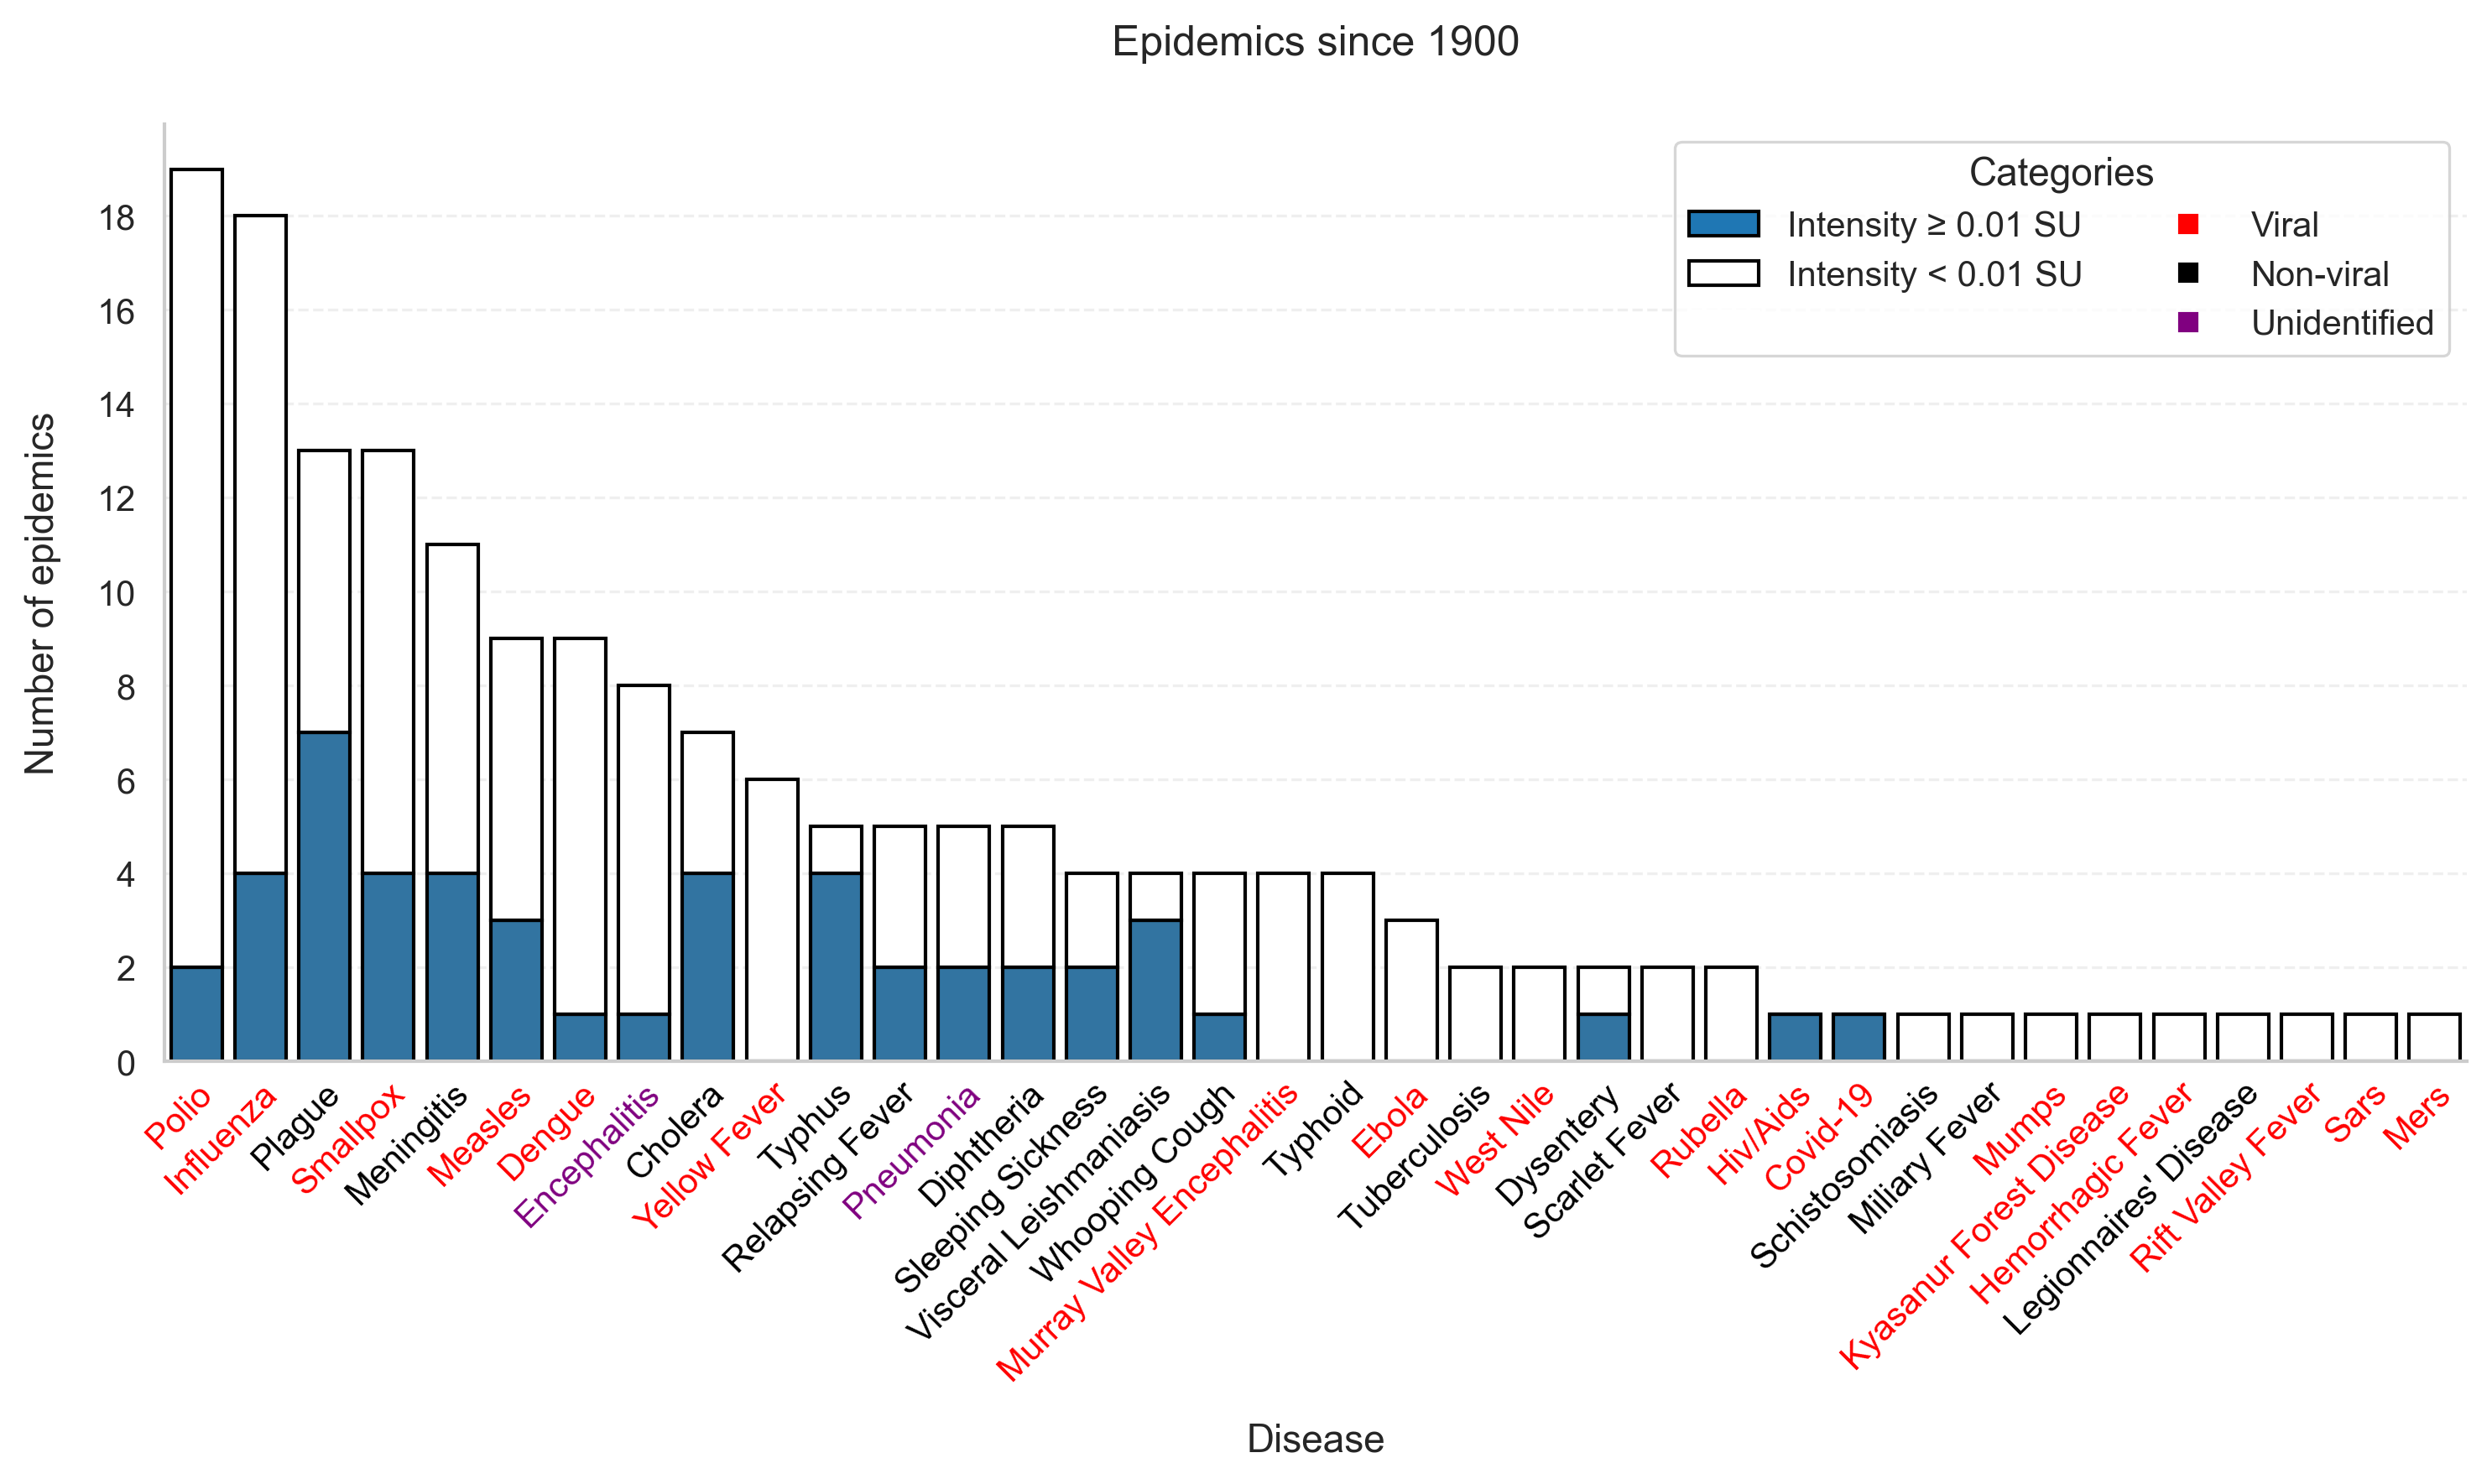

In [269]:
plot_epidemic_comparison(all_modern_ds)

In [ ]:
modern_viral_ds[['disease', 'transmission']].value_counts().sort_index(level=0)

disease                     transmission            
covid-19                    airborne/droplet             1
dengue                      bite                         9
ebola                       blood/fluid                  3
encephalitis                bite/droplet/feces/fluid     8
hemorrhagic fever           bite/fluid                   1
hiv/aids                    fluid                        1
influenza                   droplet                     18
kyasanur forest disease     bite                         1
measles                     airborne/droplet             9
meningitis                  droplet                     11
mers                        droplet                      1
mumps                       droplet                      1
murray valley encephalitis  bite                         4
pneumonia                   airborne/droplet/fluid       5
polio                       droplet/feces               19
rift valley fever           animalcontact/bite           1
rub

In [193]:
all_modern_ds['final_inclusion_node'] = all_modern_ds.apply(lambda x: get_inclusion_path(x)[-1], axis=1)
final_ds = all_modern_ds[all_modern_ds['final_inclusion_node'] == 'Novel']

C:\Users\squaade\AppData\Local\Temp\ipykernel_23488\2531010593.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



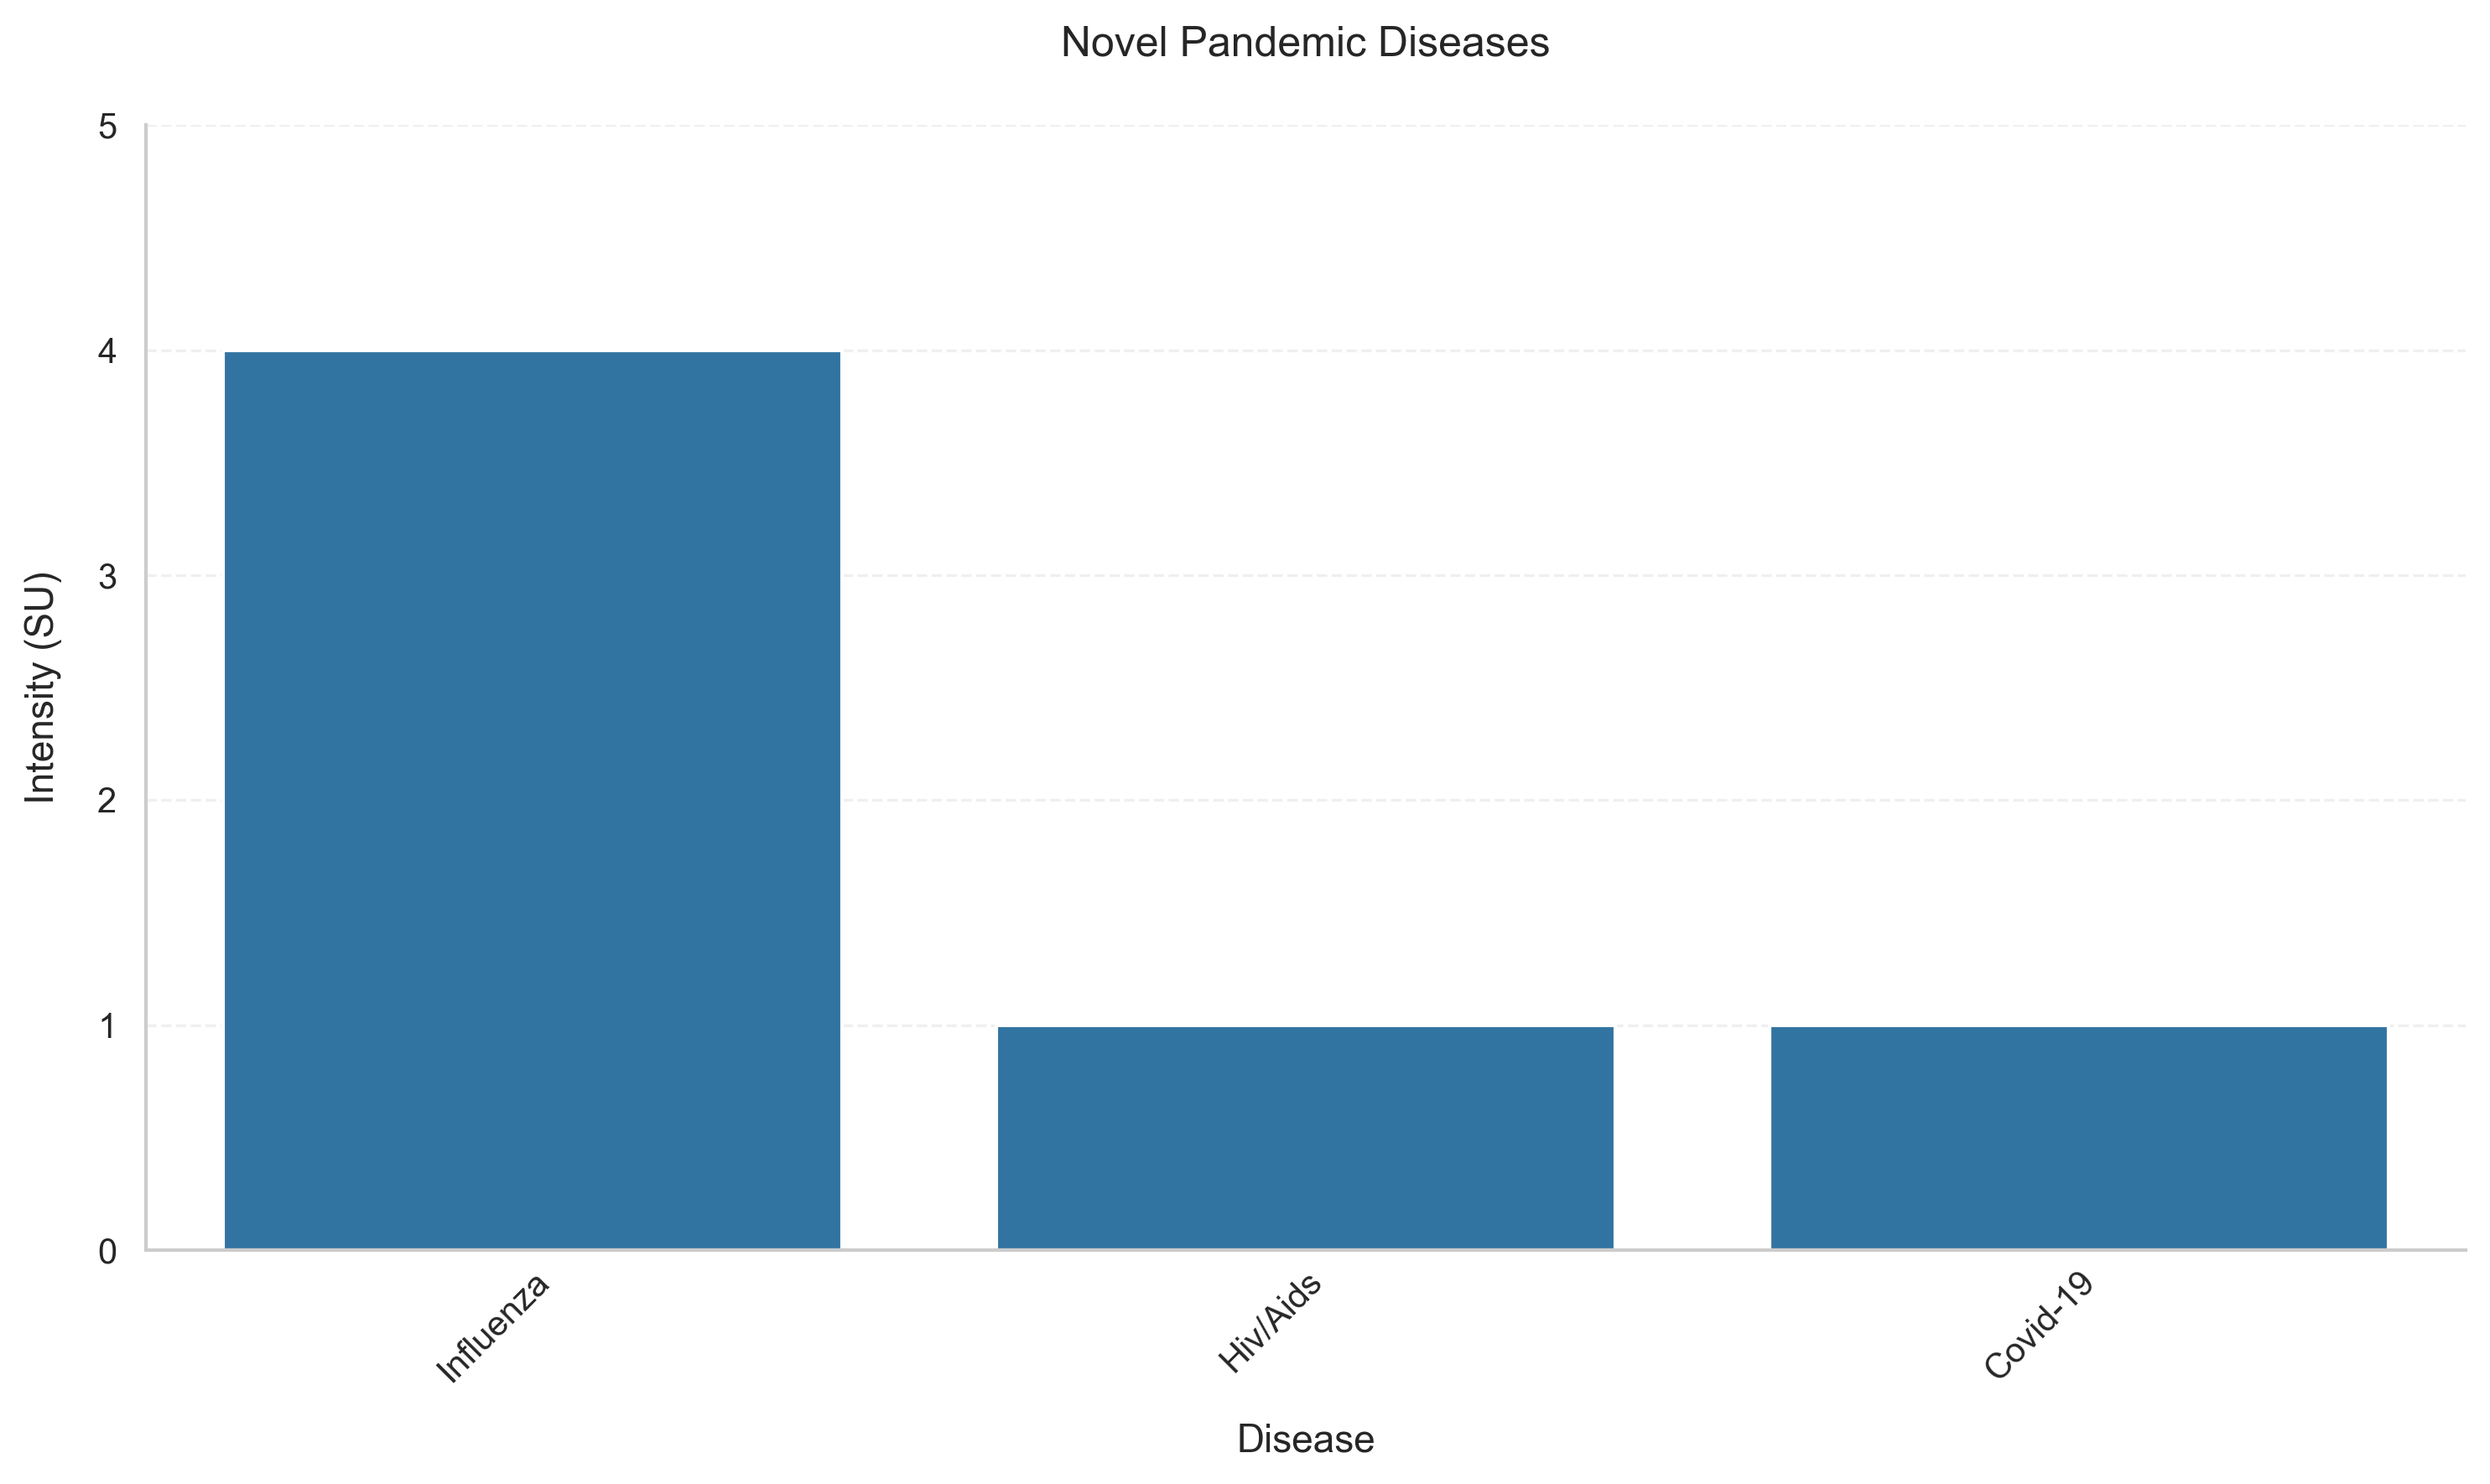

In [222]:
# Create figure with higher DPI for publication quality
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
# Create bar plot of counts
counts = final_ds['disease'].value_counts()
sns.barplot(x=counts.index, y=counts.values,
            color='#1f77b4',
            linewidth=1,
            ax=ax)

# Capitalize disease names
x_labels = [disease.title() for disease in final_ds['disease'].unique()]

# Style improvements
ax.set_title('Novel Pandemic Diseases', pad=20)
ax.set_xlabel('Disease', labelpad=10)
ax.set_ylabel('Intensity (SU)', labelpad=10)

# Set x-ticks and labels
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, ha='right', rotation=45, rotation_mode='anchor')
ax.tick_params(axis='x', pad=-0.5)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Force whole numbers
ax.set_ylim([0, max(counts) + 1])


# Remove top and right spines
ax.spines[['top', 'right']].set_visible(False)

# Add grid for better readability
ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

In [10]:
fit_dfs = {
		'All 1600-1945 (Marani)': marani_fit_ds,
		'All since 1900': all_modern_ds, 
		'Viral since 1900': modern_viral_ds,
		'Viral since 1900, no recurring': modern_viral_no_reccuring,
		'Respiratory since 1900': modern_resp_novel,
		'Novel since 1900 (Bernstein)': bernstein_intersect_ds
}

### Fit distributions

In [11]:
def get_pareto_dist(df: pd.DataFrame,
                    col: Literal['severity', 'intensity'],
                    disttype: Literal['gpd', 'trunc'],
                    lower_bound: float = 1e-2,
                    upper_bound: float = 1e4):
		"""Get exceedance distribution."""
		fit_df = df.copy()
		
		# Drop observations below lower bound
		fit_df = fit_df[fit_df[col] >= lower_bound]
				
		if disttype == 'gpd':
				c, loc, scale = genpareto.fit(fit_df[col], floc=lower_bound)
				dist = genpareto(c=c, loc=loc, scale=scale)                         
		else:
				ub = max(upper_bound, fit_df[col].max())
				dist = TruncatedGPD.fit(data=fit_df[col], fixed={'loc': lower_bound, 'upper': ub})

		return dist


def preprocess_df(df, drop_hiv, use_inverted_covid):
		new_df = df.copy()
		
		if drop_hiv:
				new_df = new_df[new_df['disease'] != 'hiv/aids']
		
		if use_inverted_covid:
				covid_mask = new_df['disease'] == 'covid-19'
				new_df.loc[covid_mask, 'severity'] = inverted_covid_severity
		
		new_df['intensity'] = new_df['severity'] / new_df['duration']
		return new_df

In [12]:
def get_upper_bound(metric: Literal['severity', 'intensity'], type: Literal['extinction', 'largest']) -> float:
		if type == 'extinction':
				return 1e4
		else:
				return 172 if metric == 'severity' else 58

In [13]:
def get_datasets_and_distributions(lower_bound=1e-2,
                                   upper_bound_type: Literal['extinction', 'largest'] = 'largest',
                                   drop_hiv=False,
                                   use_inverted_covid=False):
    """
    Creates plots comparing exceedance functions between generalized and truncated Pareto fits
    for both severity and intensity data.
    
    Args:
        lower_bound (float): Lower bound threshold for fitting distributions
        drop_hiv (bool): Whether to exclude HIV/AIDS observation
        use_inverted_covid (bool): Whether to use inverted COVID-19 severity
    
    Returns:
        dict: Dictionary containing the processed dataframes and fitted distributions
    """  
    # Process all dataframes
    processed_dfs = {name: preprocess_df(df, drop_hiv, use_inverted_covid) for name, df in fit_dfs.items()}
    
    # Fit distributions
    distributions = {}
    for name, df in processed_dfs.items():
        distributions[name] = {
            metric: {
                dist_type: get_pareto_dist(
                    df,
                    metric,
                    dist_type,
                    lower_bound,
                    get_upper_bound(metric, upper_bound_type)
                )
                for dist_type in ['gpd', 'trunc']
            }
            for metric in ['severity', 'intensity']
        }
    
    return {'dfs': processed_dfs, 'distributions': distributions}

In [14]:
# Get arrival counts for MEVD
def get_annual_arrival_counts(df: pd.DataFrame, start_year, end_year):
		years = np.arange(start_year, end_year + 1)
		arrival_counts = pd.Series(0, index=years)

		eval_df = df[df['year_start'].between(start_year, end_year)]
		df_counts = eval_df.groupby('year_start').size()
		arrival_counts.loc[df_counts.index] = df_counts

		return arrival_counts


arrival_count_dfs = {
		'All 1600-1945 (Marani)': marani_raw_ds,
		'All since 1900': all_modern_ds, 
		'Viral since 1900': modern_viral_ds,
		'Viral since 1900, no recurring': modern_viral_no_reccuring,
		'Respiratory since 1900': modern_resp_novel,
		'Novel since 1900 (Bernstein)': bernstein_intersect_ds
}
		
long_arrival_windows = {
		'All 1600-1945 (Marani)': [1600, 1945],
		'All since 1900': [1900, 2019], 
		'Viral since 1900': [1900, 2019],
		'Viral since 1900, no recurring': [1900, 2019],
		'Respiratory since 1900': [1900, 2019],
		'Novel since 1900 (Bernstein)': [1900, 2019]
}

In [15]:
modern_resp_novel[modern_resp_novel['severity'] >= 1]

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic,intensity
392,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1,56.940515
488,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1,3.480312
506,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1,1.407817
540,global covid-19,2019,2024,5,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1,1.834625


In [16]:
bernstein_intersect_ds[bernstein_intersect_ds['severity'] >= 1]

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.0,1873300.000,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,pandemic of asian flu,1957,1958,2,2000.0,2873306.000,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
2,hong kong flu,1968,1969,2,1000.0,3551599.000,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
3,hiv/aids pandemic,1981,2024,44,42300.0,4536996.619,9.323348,93.233484,hiv/aids,viral,fluid,1,0,1,1
8,global covid-19,2019,2024,6,7100.0,7740000.000,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [17]:
out = get_datasets_and_distributions(
		lower_bound=0.01,
		upper_bound_type='largest',
		drop_hiv=False,
		use_inverted_covid=False
)
processed_dfs = out['dfs']
distributions = out['distributions']

In [18]:
out['distributions']['Respiratory since 1900']['intensity']['trunc'].scale

np.float64(2.7849797914198557)

In [19]:
# Interactive plotting code
def create_arrival_plot():
    """Creates and displays the interactive plot with all controls."""
    
    def update_plot(
      	lower_bound,
        show_gpd,
        show_trunc,
        use_recent_arrival_counts,
        selected_dfs,
        use_extinction_upper,
        drop_hiv,
        use_inverted_covid
    ):
        """Updates and returns the plot based on the selected parameters.
        
        Args:
            lower_bound (float): Lower bound for fitting distributions
            show_gpd (bool): Whether to show generalized Pareto distribution curves
            show_trunc (bool): Whether to show truncated distribution curves 
            use_recent_arrival_counts (bool): Whether to use short or long run arrival counts.
            use_above_threshold_rate (bool): Whether to adjust rates for above threshold events
            selected_dfs (list): List of selected datasets to plot
            use_extinction_upper (bool): Whether to use extinction upper bounds
            drop_hiv (bool): Whether to exclude HIV data
            use_inverted_covid (bool): Whether to use inverted COVID data
            
        Returns:
            matplotlib.figure.Figure: The updated figure
        """
        # Get initial datasets and distributions
        upper_bound_type = 'extinction' if use_extinction_upper else 'largest'
        out = get_datasets_and_distributions(
						lower_bound=lower_bound,
            upper_bound_type=upper_bound_type,
						drop_hiv=drop_hiv,
						use_inverted_covid=use_inverted_covid
				)
        processed_dfs = out['dfs']
        distributions = out['distributions']

        fig, (ax_sev, ax_int) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Generate points for theoretical curves
        x = np.logspace(np.log10(lower_bound), np.log10(1e4), 1000)
        
        for name in selected_dfs:
            df = processed_dfs[name]

            # Plot for both severity and intensity
            for ax, metric in [(ax_sev, 'severity'), (ax_int, 'intensity')]:
                
                arrival_window = [2000, 2019] if use_recent_arrival_counts else long_arrival_windows[name]
                arrival_count_df = arrival_count_dfs[name]
                arrival_count_df = preprocess_df(arrival_count_df, drop_hiv, use_inverted_covid)
                arrival_count_df = arrival_count_df[arrival_count_df[metric] >= lower_bound]
                arrival_counts = get_annual_arrival_counts(arrival_count_df, *arrival_window)
                            
                if show_gpd:
                    base_dist = distributions[name][metric]['gpd']
                    mevd_gpd = MEVD(arrival_counts, base_dist)
                    y_gpd = mevd_gpd._sf(x)
                    # Set to zero above upper bound
                    upper_bound = get_upper_bound(metric, upper_bound_type)
                    y_gpd[x > upper_bound] = 0
                    ax.semilogx(x, y_gpd, label=f'{name} (GPD)', linestyle='-')
                
                if show_trunc:
                    base_dist = distributions[name][metric]['trunc']
                    mevd_trunc = MEVD(arrival_counts, base_dist)
                    y_trunc = mevd_trunc._sf(x)
                    ax.semilogx(x, y_trunc, label=f'{name} (Truncated)', linestyle='--')
        
        # Configure axes
        ax_int.legend(loc='upper right')

        for ax, title in [(ax_sev, 'Severity'), (ax_int, 'Intensity')]:
            ax.set_ylim(0, 0.4)
            ax.set_xlim(1e-3, 1e4)
            ax.set_xlabel(f'{title} (deaths per 10k)')
            ax.set_ylabel('Exceedance probability (per year)')
            ax.grid(True, which='both', ls='-', alpha=0.2)
        
        plt.tight_layout()
        return fig
    
    # Create widgets
    lower_bound_slider = widgets.FloatLogSlider(
        value=1e-2, min=-3, max=1, description='Lower bound:'
    )
    
    show_gpd = widgets.Checkbox(
        value=True, description='Show GPD'
    )
    
    show_trunc = widgets.Checkbox(
        value=True, description='Show Truncated'
    )
    
    use_recent_counts = widgets.Checkbox(
        value=True, description='Use recent arrival counts'
    )
    
    use_extinction_upper = widgets.Checkbox(
        value=False, description='Use extinction upper bounds'
    )
    
    drop_hiv = widgets.Checkbox(
        value=False, description='Drop HIV'
    )
    
    use_inverted_covid = widgets.Checkbox(
        value=False, description='Use inverted COVID'
    )
    
    df_toggles = widgets.SelectMultiple(
        options=[
						'All 1600-1945 (Marani)',
						'All since 1900',
						'Viral since 1900',
						'Viral since 1900, no recurring',
						'Respiratory since 1900',
						'Novel since 1900 (Bernstein)',
        ],
        value=['All 1600-1945 (Marani)'],
        description='Datasets:'
    )
    
    # Create interactive plot
    interactive_plot = widgets.interactive(
        update_plot,
        lower_bound=lower_bound_slider,
        show_gpd=show_gpd,
        show_trunc=show_trunc,
        use_recent_arrival_counts=use_recent_counts,
        selected_dfs=df_toggles,
        use_extinction_upper=use_extinction_upper,
        drop_hiv=drop_hiv,
        use_inverted_covid=use_inverted_covid
    )
    
    # Layout widgets and plot
    controls = widgets.VBox([
        df_toggles,
        widgets.HBox([lower_bound_slider, show_gpd, show_trunc, use_recent_counts]),
        widgets.HBox([use_extinction_upper, drop_hiv, use_inverted_covid])
    ])
    
    return widgets.VBox([controls, interactive_plot.children[-1]])


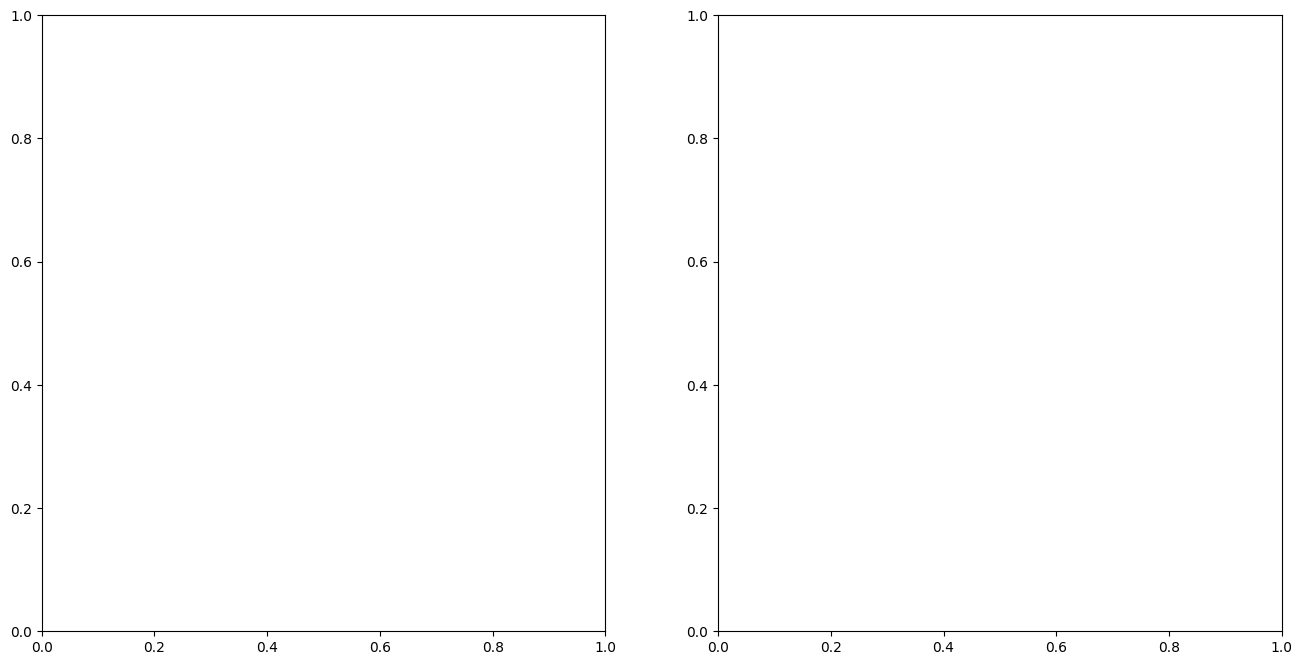

In [20]:
create_arrival_plot()

In [21]:
def create_duration_plot():
    """Creates and displays the interactive duration plot with all controls."""
    
    def update_plot(
        selected_dfs,
        lower_bound,
        drop_hiv,
        max_duration
    ):
        """Updates and returns the plot based on the selected parameters.
        
        Args:
            selected_dfs (list): List of selected datasets to plot
            lower_bound (float): Lower bound for fitting distributions
            drop_hiv (bool): Whether to exclude HIV data
            max_duration (bool): Whether to use inverted COVID data
            
        Returns:
            matplotlib.figure.Figure: The updated figure
        """
        # Get selected datasets
        out = get_datasets_and_distributions(
						lower_bound=lower_bound,
						drop_hiv=drop_hiv
        )
        processed_dfs = out['dfs']

        fig, ax = plt.subplots(figsize=(12, 8))
        
        if max_duration is None:
            max_x = max([df['duration'].max() for df in processed_dfs]) + 2
        else:
            max_x = max_duration + 1
        
        x = np.linspace(0, max_x, 1000)
        
				# Fit and plot
        means = {}
        for name in selected_dfs:
            df = processed_dfs[name]
            
						# Consider adding max duration later
            s, loc, scale = lognorm.fit(df['duration'], floc=0)
            exceedance = lognorm.sf(x, s, loc=loc, scale=scale)
            exceedance[x > max_duration] = 0
            ax.plot(x, exceedance, label=f'{name}')
            
            # Mean with truncation - mass below * conditional mean + mass above * max duration
            # Calculate truncated mean: E[min(X, max_duration)]
            cdf_at_max = lognorm.cdf(max_duration, s, loc=loc, scale=scale)
            mean = (
                lognorm.expect(lambda x: x, args=(s,), loc=loc, scale=scale, lb=0, ub=max_duration) * cdf_at_max +
                max_duration * (1 - cdf_at_max)
            )
            means[name] = mean
            # Plot vertical line at the mean
            ax.axvline(x=mean, linestyle='--', color=ax.lines[-1].get_color(), alpha=0.7)
        
        # Configure axes
        legend_entries = []
        for name in selected_dfs:
            legend_entries.append(f'{name}')
            legend_entries.append(f'{name} mean ({means[name]:.2f} years)')
        
        ax.legend(loc='upper right')
        ax.set_xlabel('Years')
        ax.set_ylabel('Exceedance probability')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, 1)
        
        plt.tight_layout()
        return fig
    
    # Create widgets
    lower_bound_slider = widgets.FloatLogSlider(
        value=1e-2, min=-3, max=1, description='Lower bound:'
    )
    
    drop_hiv = widgets.Checkbox(
        value=False, description='Drop HIV'
    )
    
    max_duration = widgets.IntSlider(
        value=10, min=1, max=150, description='Max duration:'
    )
    
    df_toggles = widgets.SelectMultiple(
        options=[
						'All 1600-1945 (Marani)',
						'All since 1900',
						'Viral since 1900',
						'Viral since 1900, no recurring',
						'Respiratory since 1900',
						'Novel since 1900 (Bernstein)',
        ],
        value=['All 1600-1945 (Marani)'],
        description='Datasets:'
    )
    
    # Create interactive plot
    interactive_plot = widgets.interactive(
        update_plot,
        selected_dfs=df_toggles,
        lower_bound=lower_bound_slider,
        drop_hiv=drop_hiv,
        max_duration=max_duration
    )
    
    # Layout widgets and plot
    controls = widgets.VBox([
        df_toggles,
        widgets.HBox([lower_bound_slider, max_duration, drop_hiv])
    ])
    
    return widgets.VBox([controls, interactive_plot.children[-1]])


In [22]:
create_duration_plot()

In [23]:
def create_mortality_plot(
    selected_dfs=['All 1600-1945 (Marani)', 'Novel since 1900 (Bernstein)'],
    lower_bound=1e-2,
    drop_hiv=False,
    use_inverted_covid=False,
    use_extinction_upper=False,
    max_duration=10,
    arrival_window: Literal['short', 'long'] = 'long',
    n_samples=1e5
):
    """Creates and displays a plot showing expected annual mortality.
    
    Args:
        selected_dfs (list): List of selected datasets to plot
        lower_bound (float): Lower bound for fitting distributions
        drop_hiv (bool): Whether to exclude HIV data
        use_inverted_covid (bool): Whether to use inverted COVID data
        use_extinction_upper (bool): Whether to use extinction upper bounds
        max_duration (int): Maximum duration to consider
        n_samples (int): Number of Monte Carlo samples
        
    Returns:
        matplotlib.figure.Figure: The figure with mortality estimates
    """
    # Get datasets and distributions
    upper_bound_type = 'extinction' if use_extinction_upper else 'largest'
    out = get_datasets_and_distributions(
        lower_bound=lower_bound,
        upper_bound_type=upper_bound_type,
        drop_hiv=drop_hiv,
        use_inverted_covid=use_inverted_covid
    )
    processed_dfs = out['dfs']
    distributions = out['distributions']
    death_quantiles = np.random.rand(int(n_samples))
    duration_quantiles = np.random.rand(int(n_samples))
    
    # Current world population
    population = 7.91e9 / 1e4  # Convert to 10k person units
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Set up bar positions
    n_datasets = len(selected_dfs)
    bar_width = 0.15
    index = np.arange(n_datasets)
    
    # Colors for different metrics and distribution types
    colors = {
        'severity': {'gpd': 'royalblue', 'trunc': 'lightblue'},
        'intensity': {'gpd': 'firebrick', 'trunc': 'lightcoral'}
    }
    
    # Store results for plotting
    results = {dataset: {'severity': {}, 'intensity': {}} for dataset in selected_dfs}
    
    # Calculate expected annual deaths for each dataset and distribution
    for i, name in enumerate(selected_dfs):
        df = processed_dfs[name]
        
        # Get duration distribution parameters
        duration_data = df['duration']
        s, loc, scale = lognorm.fit(duration_data, floc=0)
        
        for dist_type in ['gpd', 'trunc']:
            for metric in ['severity', 'intensity']:
                base_dist = distributions[name][metric][dist_type]
                window = [2000, 2019] if arrival_window == 'short' else long_arrival_windows[name]
                arrival_count_df = preprocess_df(arrival_count_dfs[name], drop_hiv, use_inverted_covid)
                arrival_count_df = arrival_count_df[arrival_count_df[metric] >= lower_bound]
                arrival_counts = get_annual_arrival_counts(arrival_count_df, *window)
                
                mevd = MEVD(arrival_counts, base_dist)
                
                # Generate samples
                upper_bound = get_upper_bound(metric, upper_bound_type)
                upper_bound = max(upper_bound, processed_dfs[name][metric].max())

                mortality_draws = mevd.ppf(
                    death_quantiles,
                  	min_x=lower_bound, 
                  	max_x=upper_bound,
                    max_iter=600,
                    tol=1e-4
                )
                
                durations = np.minimum(
										lognorm.ppf(duration_quantiles, s, loc=loc, scale=scale),
										max_duration
								)
                
                if metric == 'severity':
                    # For severity, divide by duration
                    durations = np.round(durations, decimals=0)
                    annual_deaths = mortality_draws * population
                else:
                    annual_deaths = mortality_draws * population * durations
                
                results[name][metric][dist_type] = np.mean(annual_deaths)
    
    # Plot the results
    for i, dataset in enumerate(selected_dfs):
        # Position bars for this dataset
        pos = i
        group_gap = 0.05  # Gap between severity and intensity groups
        
        # Plot severity bars
        ax.bar(pos - (1.5*bar_width + group_gap/2), results[dataset]['severity']['gpd'], 
               width=bar_width, color=colors['severity']['gpd'], 
               label='Severity (GPD)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
        
        ax.bar(pos - (0.5*bar_width + group_gap/2), results[dataset]['severity']['trunc'], 
               width=bar_width, color=colors['severity']['trunc'], 
               label='Severity (TRUNC)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
        
        # Plot intensity bars
        ax.bar(pos + (0.5*bar_width + group_gap/2), results[dataset]['intensity']['gpd'], 
               width=bar_width, color=colors['intensity']['gpd'], 
               label='Intensity (GPD)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
        
        ax.bar(pos + (1.5*bar_width + group_gap/2), results[dataset]['intensity']['trunc'], 
               width=bar_width, color=colors['intensity']['trunc'], 
               label='Intensity (TRUNC)' if i == 0 else "", 
               edgecolor='black', linewidth=0.5, alpha=0.9)
    
    # Configure axis with improved styling
    ax.set_ylabel('Expected Annual Deaths', fontsize=12, fontweight='bold')
    ax.set_title('Expected Annual Deaths by Dataset', fontsize=14, fontweight='bold')
    ax.set_xticks(index)
    ax.set_xticklabels([name.split(' (')[0] for name in selected_dfs], rotation=45, ha='right', fontsize=10)
    
    # Improve grid and overall appearance
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Add thousands separator to y-axis
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(frameon=True, framealpha=0.9, fontsize=10,
              loc='upper right', edgecolor='lightgray', fancybox=True)
    
    # Add subtle background color
    ax.set_facecolor('#f8f8f8')
    
    plt.tight_layout()

KeyboardInterrupt: 

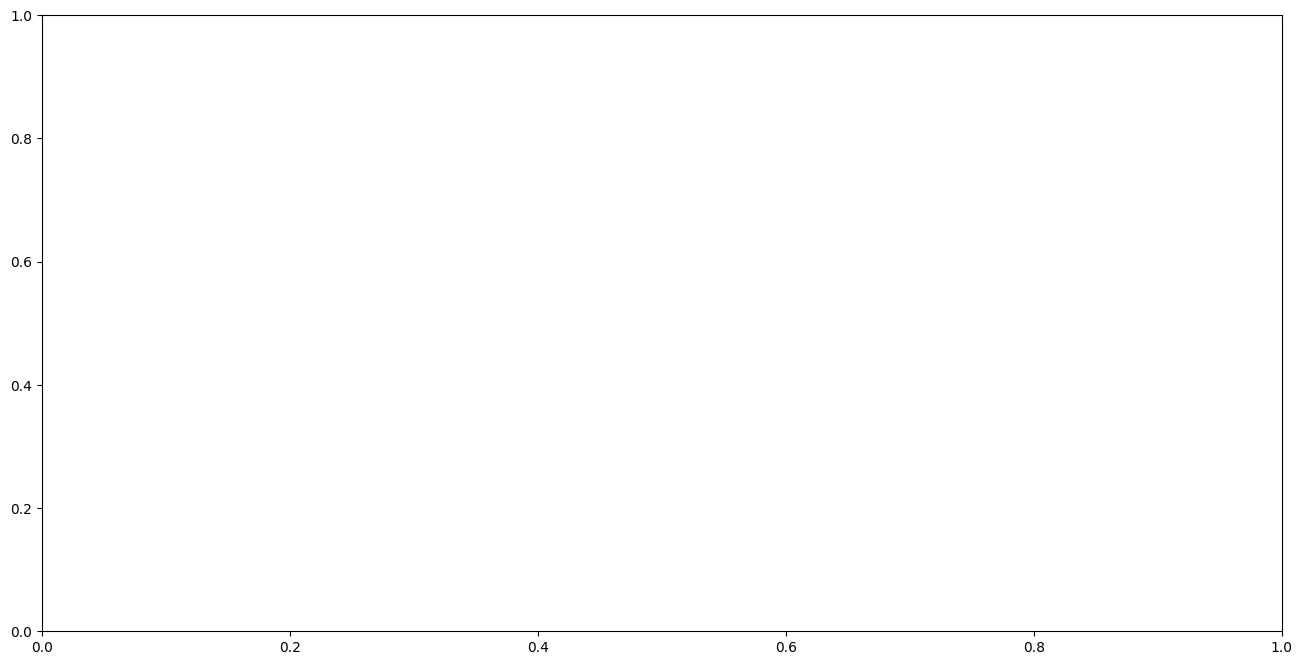

In [24]:
create_mortality_plot(selected_dfs=['All 1600-1945 (Marani)', 'Respiratory since 1900', 'Novel since 1900 (Bernstein)'], lower_bound=2e-2)

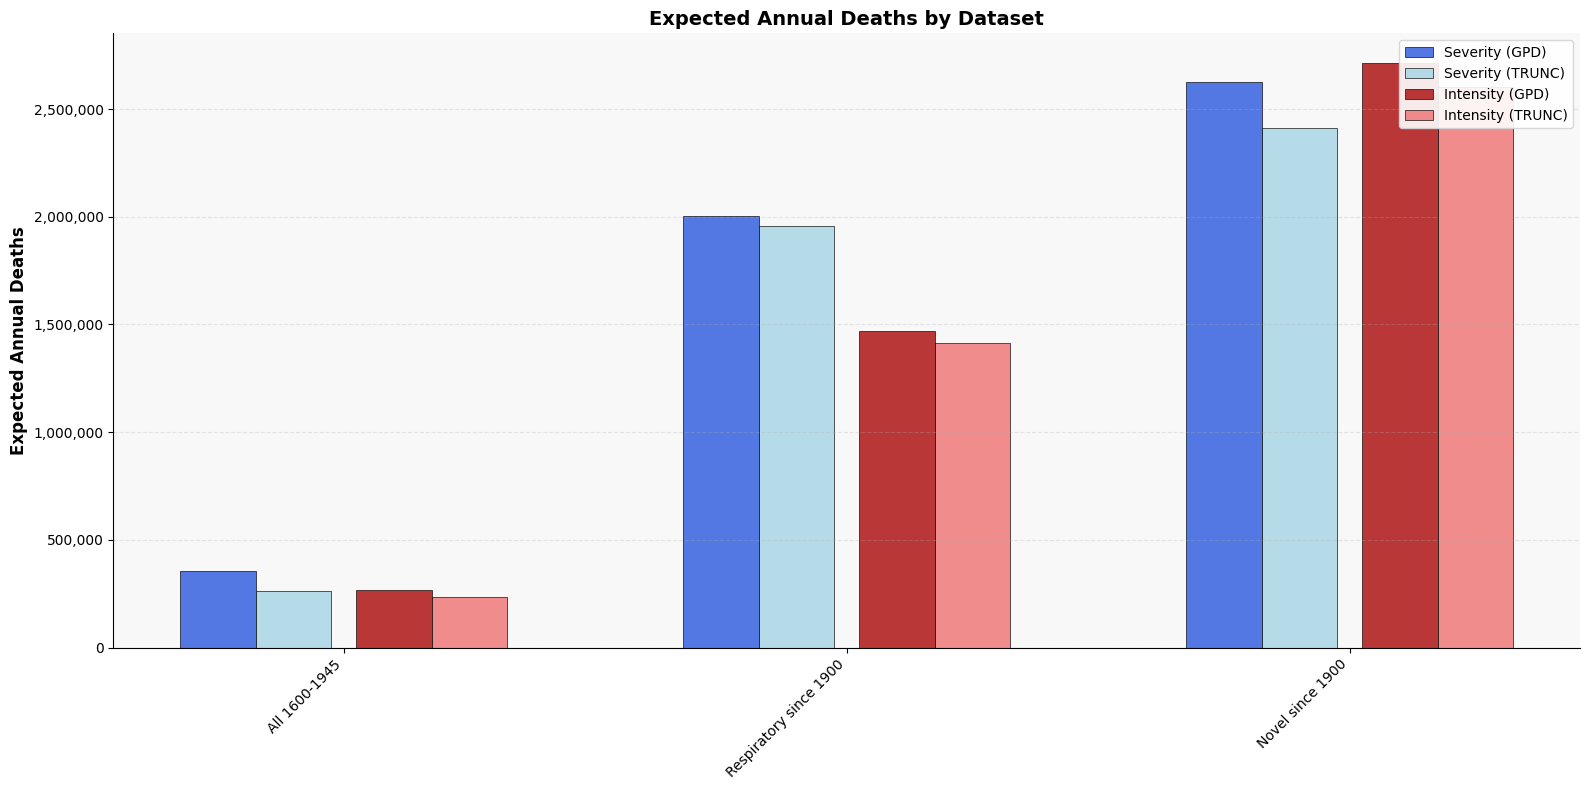

In [117]:
create_mortality_plot(selected_dfs=['All 1600-1945 (Marani)', 'Respiratory since 1900', 'Novel since 1900 (Bernstein)'], lower_bound=2e-2, arrival_window='short')

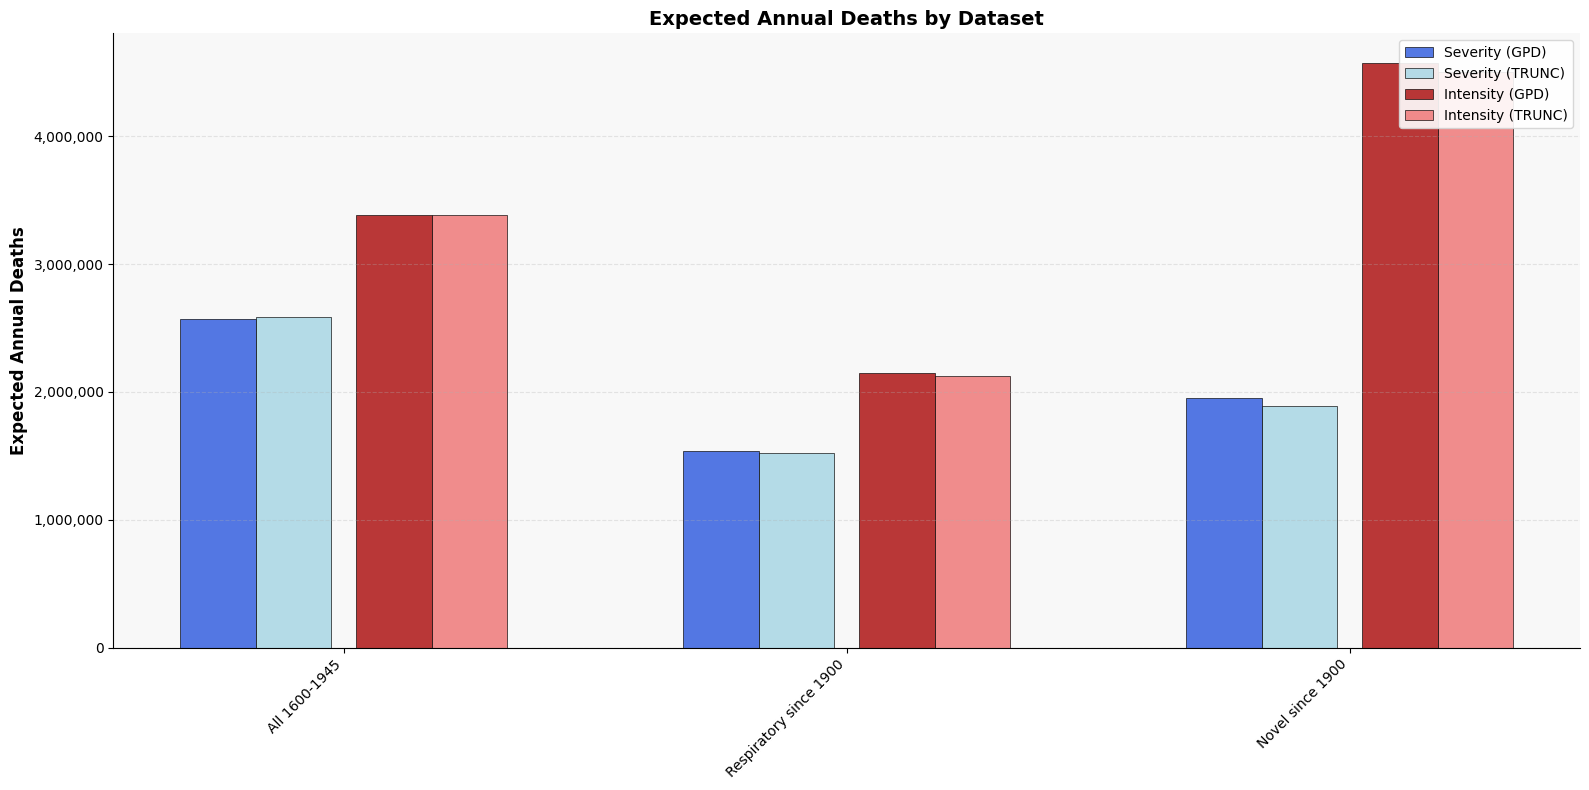

In [118]:
create_mortality_plot(selected_dfs=['All 1600-1945 (Marani)', 'Respiratory since 1900', 'Novel since 1900 (Bernstein)'], lower_bound=1)

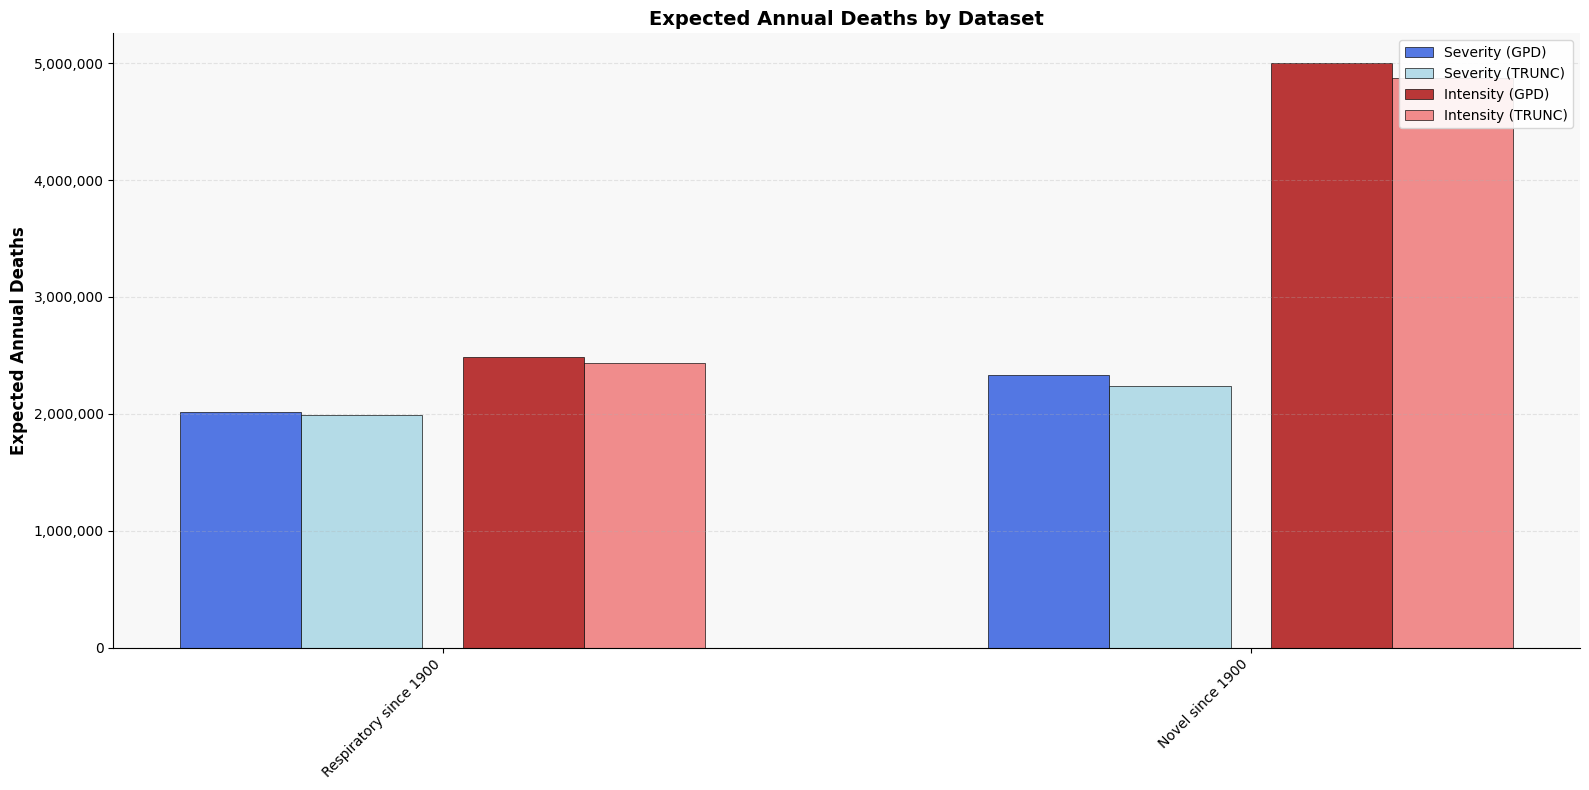

In [119]:
create_mortality_plot(selected_dfs=['Respiratory since 1900', 'Novel since 1900 (Bernstein)'], lower_bound=1, arrival_window='short')